# Refseq dataset , statistical analysis

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from natsort import natsorted


In [7]:
raw_stat_file = "/home/hcourtei/Projects/MicroTaxo/codes/data/raw_taxonomy_refseq_data.csv"
raw_taxonomy_data =  pd.read_csv(raw_stat_file, sep=";")
raw_taxonomy_data


,Groupe,domain,phylum,group,order,family,specie,ID
0,group_0,Bacteria,Campylobacterota,Epsilonproteobacteria,Campylobacterales,Campylobacter,hyointestinalis,0
1,group_0,Bacteria,Campylobacterota,Epsilonproteobacteria,Campylobacterales,Helicobacter,pylori,0
2,group_0,Bacteria,Campylobacterota,Epsilonproteobacteria,Campylobacterales,Campylobacter,showae,0
3,group_0,Bacteria,Spirochaetota,Spirochaetia,Spirochaetales,Borrelia,anserina,0
4,group_0,Bacteria,Spirochaetota,Spirochaetia,Leptospirales,Leptospira,interrogans,0
...,...,...,...,...,...,...,...,...
77,group_1,Bacteria,Pseudomonadati,Pseudomonadota,Pseudomonadales,Pseudomonas,aeruginosa,18
78,group_1,Bacteria,Pseudomonadati,Pseudomonadota,Pseudomonadales,Pseudomonas,aeruginosa,20
79,group_1,Bacteria,Pseudomonadati,Pseudomonadota,Pseudomonadales,Pseudomonas,aeruginosa,12
80,group_1,Bacteria,Pseudomonadati,Pseudomonadota,Pseudomonadales,Pseudomonas,aeruginosa,21


In [9]:
counts_per_species = (
    raw_taxonomy_data
    .groupby(["domain", "phylum", "group", "order", "family", "specie"])['id']
    .nunique()
    .reset_index(name='Effectif')
)
counts_per_species.sort_values(by='Effectif', ascending=False)

,domain,phylum,group,order,family,specie,Effectif
40,Bacteria,Pseudomonadati,Pseudomonadota,Pseudomonadales,Pseudomonas,aeruginosa,24
0,Bacteria,Campylobacterota,Epsilonproteobacteria,Campylobacterales,Campylobacter,coli,1
44,Bacteria,Spirochaetota,Spirochaetia,Brachyspirales,Brachyspira,hyodysenteriae,1
32,Bacteria,Pseudomonadati,Pseudomonadota,Enterobacterales,Klebsiella,aerogenes,1
33,Bacteria,Pseudomonadati,Pseudomonadota,Enterobacterales,Pantoea,agglomerans,1
34,Bacteria,Pseudomonadati,Pseudomonadota,Hyphomicrobiales,Brucella,abortus,1
35,Bacteria,Pseudomonadati,Pseudomonadota,Hyphomicrobiales,Methylocystis,parvus,1
36,Bacteria,Pseudomonadati,Pseudomonadota,Lysobacterales,Lysobacter,enzymogenes,1
37,Bacteria,Pseudomonadati,Pseudomonadota,Neisseriales,Simonsiella,muelleri,1
38,Bacteria,Pseudomonadati,Pseudomonadota,Neisseriales,Vitreoscilla,filiformis,1


## Nombre de génomes par famille

In [12]:
counts_per_family = (
    counts_per_species
    .groupby(['domain', 'phylum', 'group', 'order', 'family'])['Effectif']
    .sum()
    .reset_index()
)

counts_per_family = counts_per_family.sort_values(by='Effectif', ascending=False)
count_per_family_print = counts_per_family.drop(columns=['domain']).reset_index(drop=True).copy()
max_length =25
for col in ['phylum', 'group', 'order', 'family']:
    count_per_family_print[col] = count_per_family_print[col].apply(
        lambda x: x[:max_length] + '...' if len(x) > max_length else x
    )

print(count_per_family_print.to_markdown())



|    | phylum           | group                 | order             | family            |   Effectif |
|---:|:-----------------|:----------------------|:------------------|:------------------|-----------:|
|  0 | Pseudomonadati   | Pseudomonadota        | Pseudomonadales   | Pseudomonas       |         24 |
|  1 | Campylobacterota | Epsilonproteobacteria | Campylobacterales | Campylobacter     |         10 |
|  2 | Spirochaetota    | Spirochaetia          | Spirochaetales    | Borrelia          |          5 |
|  3 | Spirochaetota    | Spirochaetia          | Spirochaetales    | Treponema         |          5 |
|  4 | Campylobacterota | Epsilonproteobacteria | Campylobacterales | Helicobacter      |          3 |
|  5 | Spirochaetota    | Spirochaetia          | Leptospirales     | Leptospira        |          2 |
|  6 | Pseudomonadati   | Pseudomonadota        | Neisseriales      | Vitreoscilla      |          2 |
|  7 | Pseudomonadati   | Pseudomonadota        | Burkholderiales   | Bor

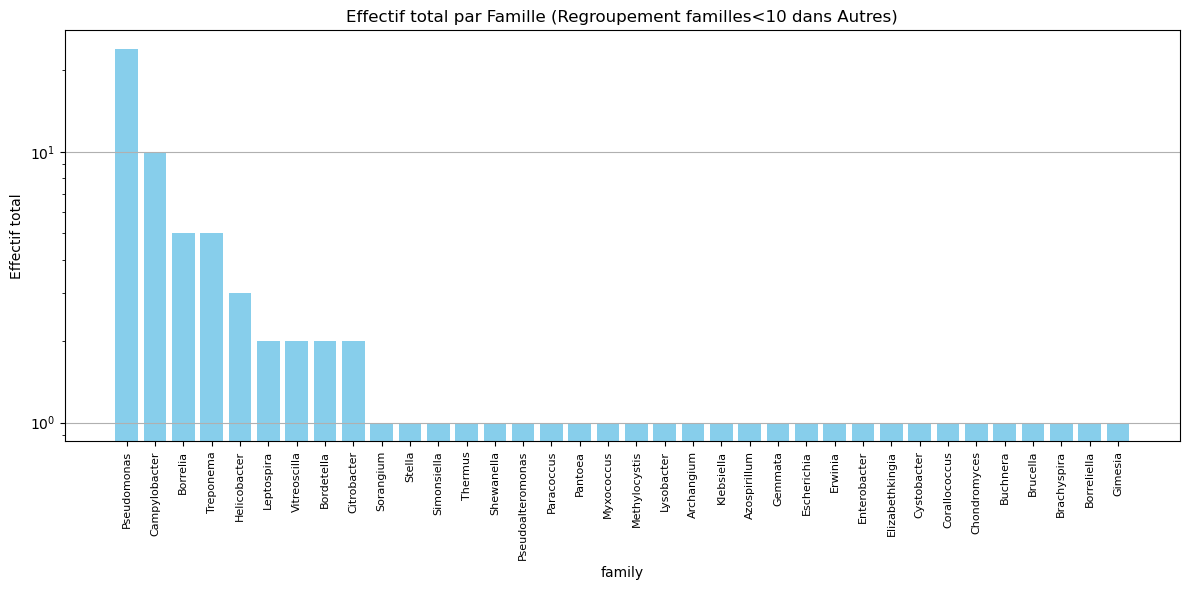

In [14]:
threshold = 1  # Seuil d'effectif
counts_per_family["Family_Grouped"] = counts_per_family.apply(
    lambda row: row["family"] if row["Effectif"] >= threshold else "Autres", axis=1
)
# Calculer les effectifs par famille ou groupe "Autres"
grouped_families = counts_per_family.groupby("Family_Grouped")["Effectif"].sum().reset_index()
# Trier les familles par effectif décroissant
grouped_families_sorted = grouped_families.sort_values(by="Effectif", ascending=False)
# Création du graphique avec échelle semi-logarithmique
plt.figure(figsize=(12, 6))
plt.bar(grouped_families_sorted["Family_Grouped"], grouped_families_sorted["Effectif"], color="skyblue")
plt.yscale('log')  # Appliquer une échelle log sur l'axe y
plt.xticks(rotation=90, fontsize=8)  # Rotation des labels et diminution de la taille des légendes
plt.xlabel('family')
plt.ylabel('Effectif total')
plt.title('Effectif total par Famille (Regroupement familles<10 dans Autres)')
plt.tight_layout()
plt.grid(axis='y')
plt.show()